In [423]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/diabetes.csv")

df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
255,1,113,64,35,0,33.6,0.543,21,1
206,8,196,76,29,280,37.5,0.605,57,1
89,1,107,68,19,0,26.5,0.165,24,0
414,0,138,60,35,167,34.6,0.534,21,1


In [398]:
df.shape

(768, 9)

In [399]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [400]:
#Analise Visual

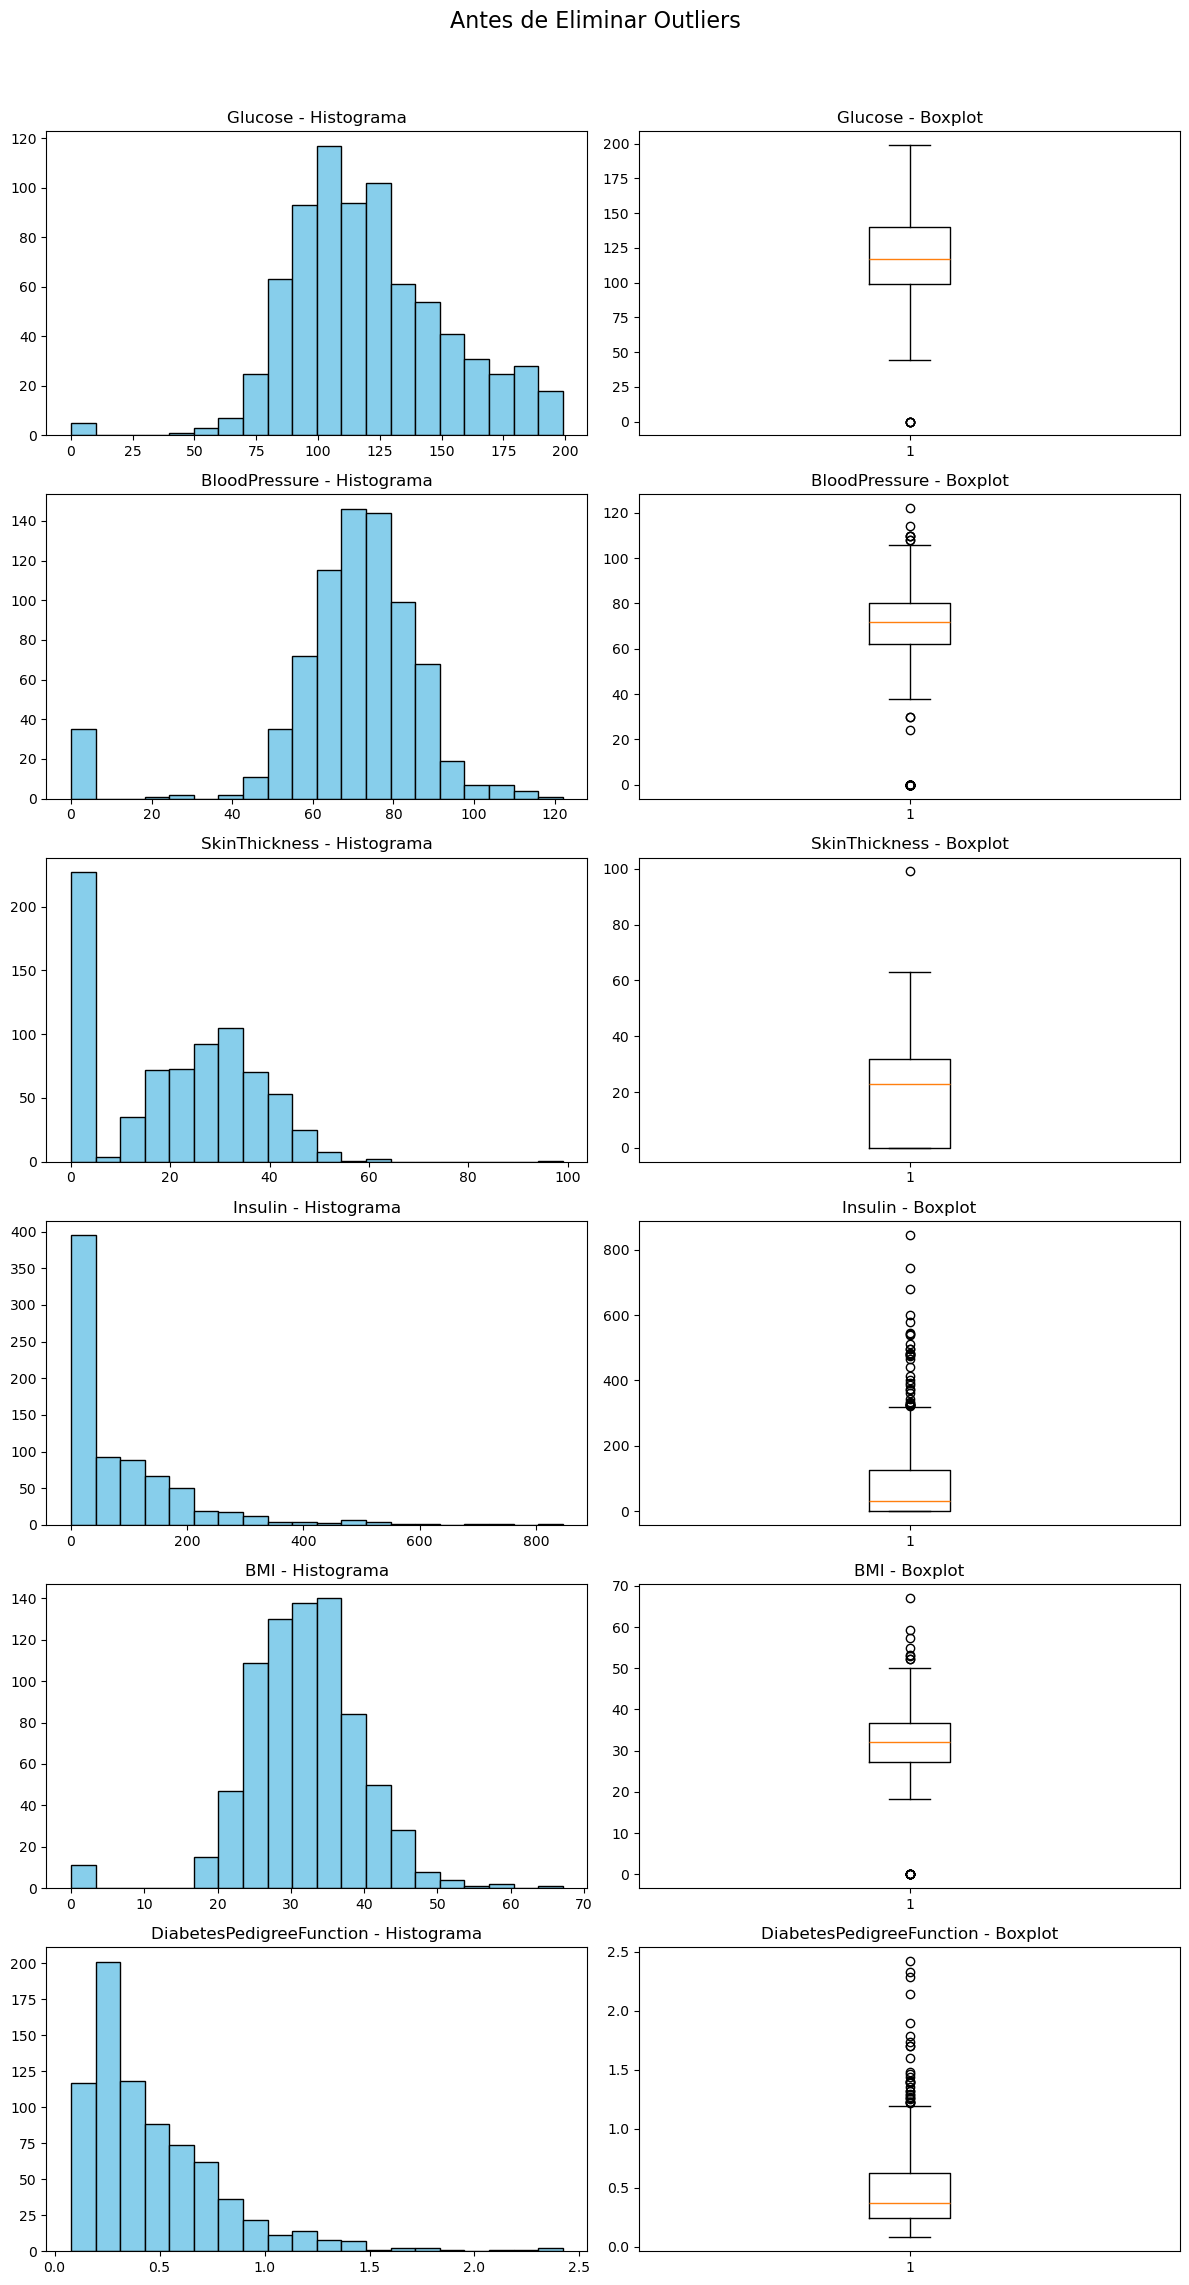

In [401]:
colunas = ['Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction']

plt.figure(figsize=(12,24))
for i, col in enumerate(colunas):
    # Histograma à esquerda
    plt.subplot(len(colunas), 2, 2*i + 1)
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'{col} - Histograma')

    # Boxplot à direita
    plt.subplot(len(colunas), 2, 2*i + 2)
    plt.boxplot(df[col], vert=True)
    plt.title(f'{col} - Boxplot')


plt.suptitle("Antes de Eliminar Outliers", fontsize=16, y=0.95)
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [402]:
#Alguns dados são impossiveis de ser zero(como por exemplo, Glucose)

for col in colunas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1

    limite_inferior = q1 - (1.5 *IQR)
    limite_superior = q3 + (1.5 *IQR)

    print("coluna: ",col)
    print(limite_inferior)
    print(limite_superior)

coluna:  Glucose
37.125
202.125
coluna:  BloodPressure
35.0
107.0
coluna:  SkinThickness
-48.0
80.0
coluna:  Insulin
-190.875
318.125
coluna:  BMI
13.35
50.550000000000004
coluna:  DiabetesPedigreeFunction
-0.32999999999999996
1.2


In [403]:
outliers = (
    (df['Glucose'].lt(37.13) | df['Glucose'].gt(202.13)) |
    (df['BloodPressure'].lt(35) | df['BloodPressure'].gt(107)) |
    (df['SkinThickness'].lt(-48) | df['SkinThickness'].gt(80)) |
    (df['Insulin'].lt(-190) | df['Insulin'].gt(318)) |
    (df['BMI'].lt(-13.5) | df['BMI'].gt(51)) |
    (df['DiabetesPedigreeFunction'].lt(-0.33) | df['DiabetesPedigreeFunction'].gt(1.2))
)

df = df[~outliers]
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
635,13,104,72,0,0,31.2,0.465,38,1
423,2,115,64,22,0,30.8,0.421,21,0
709,2,93,64,32,160,38.0,0.674,23,1
726,1,116,78,29,180,36.1,0.496,25,0
55,1,73,50,10,0,23.0,0.248,21,0


In [404]:
df.shape

(653, 9)

In [405]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
mean,3.892802,119.370597,72.214395,20.431853,65.234303,31.863706,0.429642,33.249617,0.316998
std,3.368588,29.330001,11.315741,15.363900,79.306340,6.767396,0.250147,11.773574,0.465664
min,0.000000,44.000000,38.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.200000,0.239000,24.000000,0.000000
50%,3.000000,114.000000,72.000000,23.000000,36.000000,32.000000,0.361000,29.000000,0.000000
75%,6.000000,137.000000,80.000000,32.000000,120.000000,36.000000,0.586000,41.000000,1.000000
max,17.000000,198.000000,106.000000,60.000000,318.000000,50.000000,1.191000,81.000000,1.000000


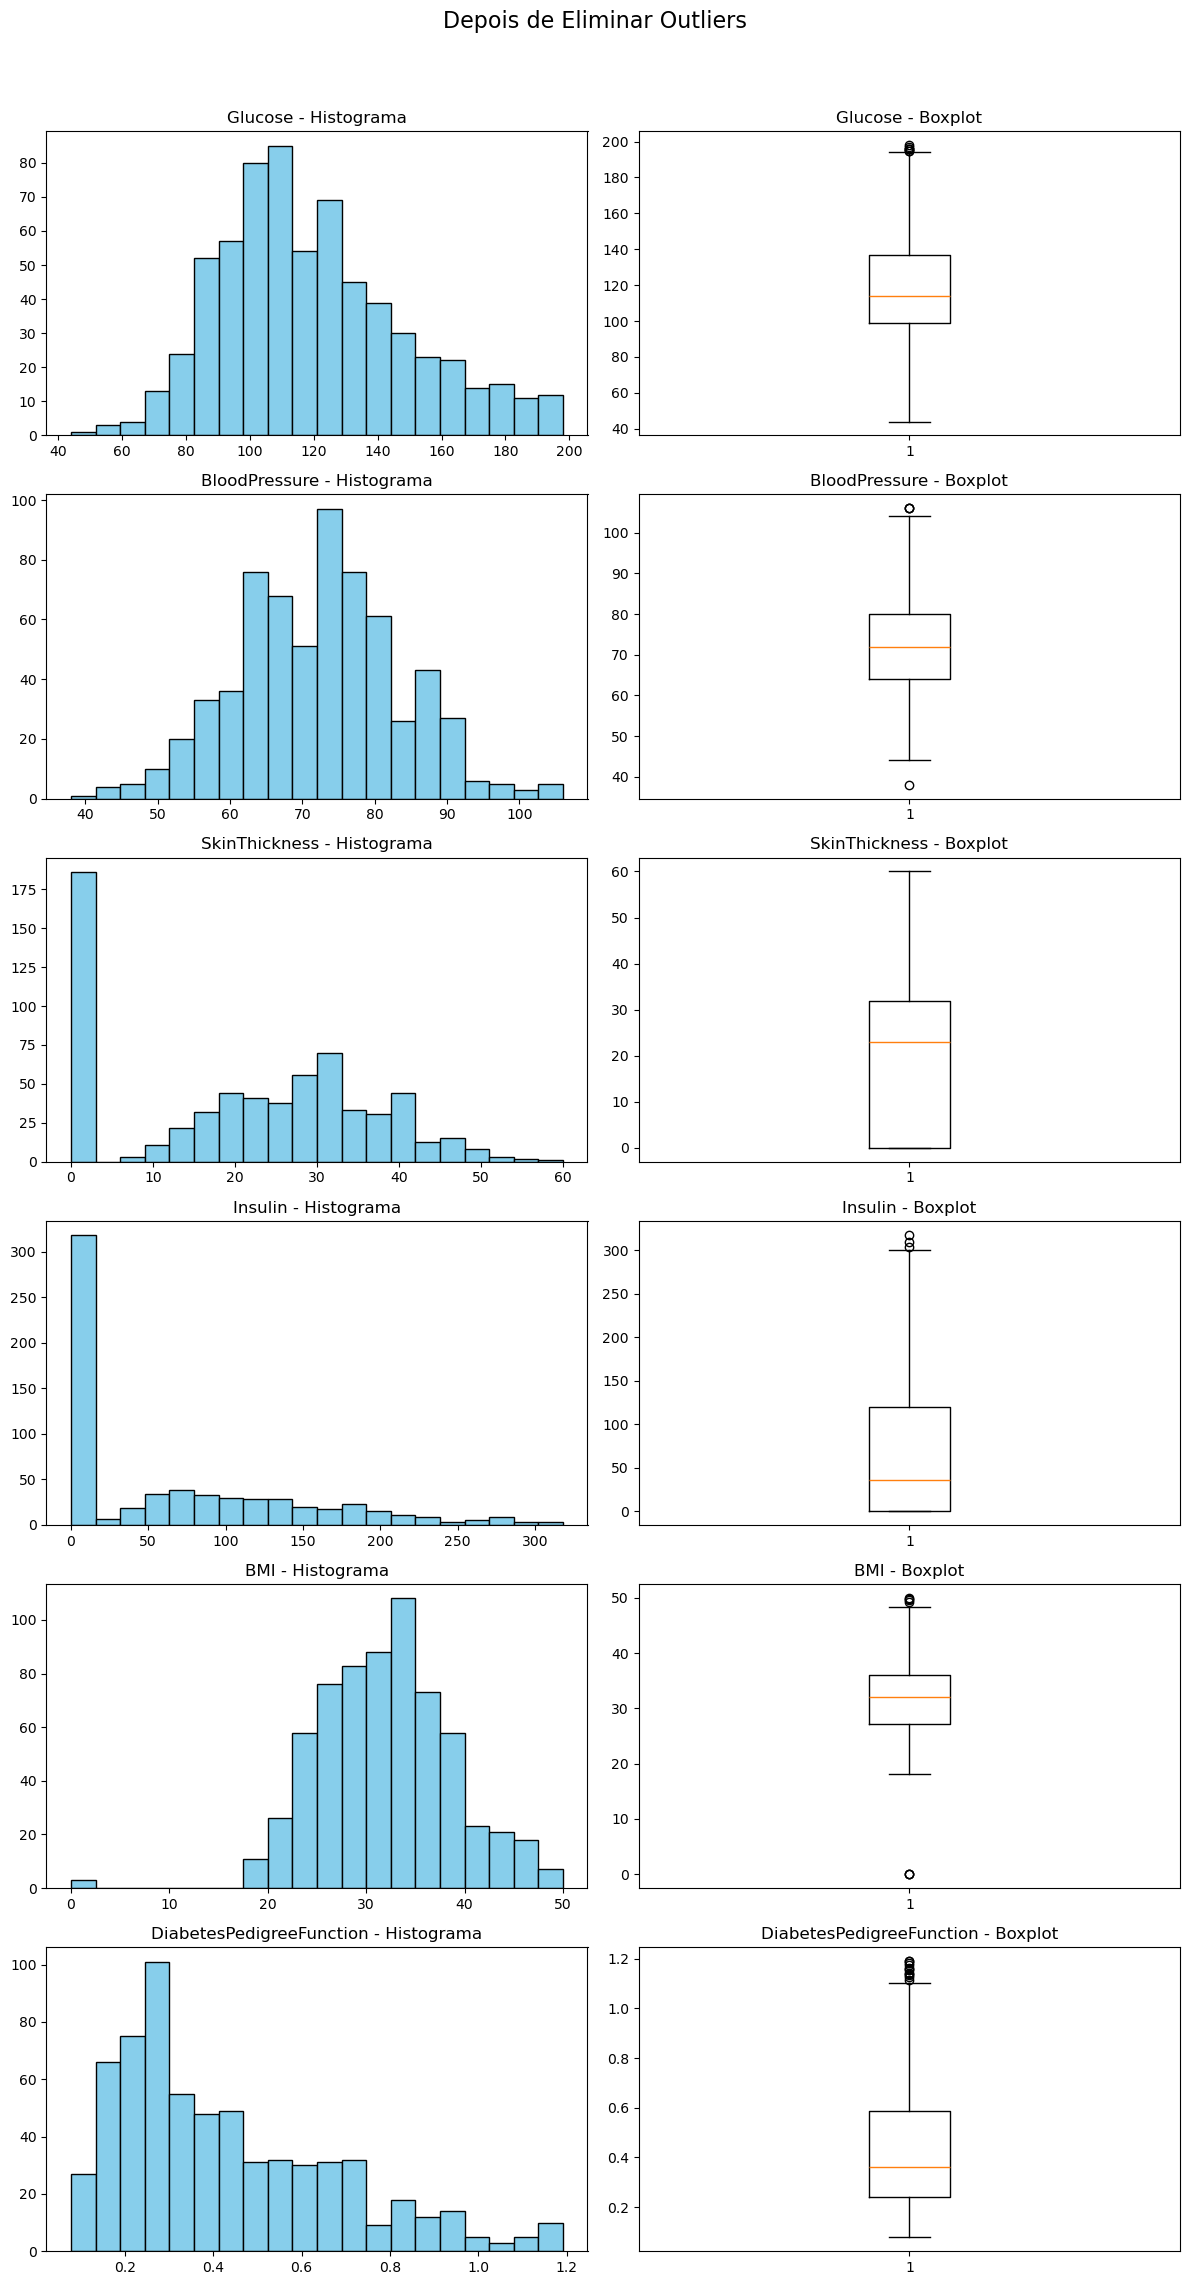

In [406]:
plt.figure(figsize=(12,24))
for i, col in enumerate(colunas):
    # Histograma à esquerda
    plt.subplot(len(colunas), 2, 2*i + 1)
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'{col} - Histograma')

    # Boxplot à direita
    plt.subplot(len(colunas), 2, 2*i + 2)
    plt.boxplot(df[col], vert=True)
    plt.title(f'{col} - Boxplot')

plt.suptitle("Depois de Eliminar Outliers", fontsize=16, y=0.95)
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

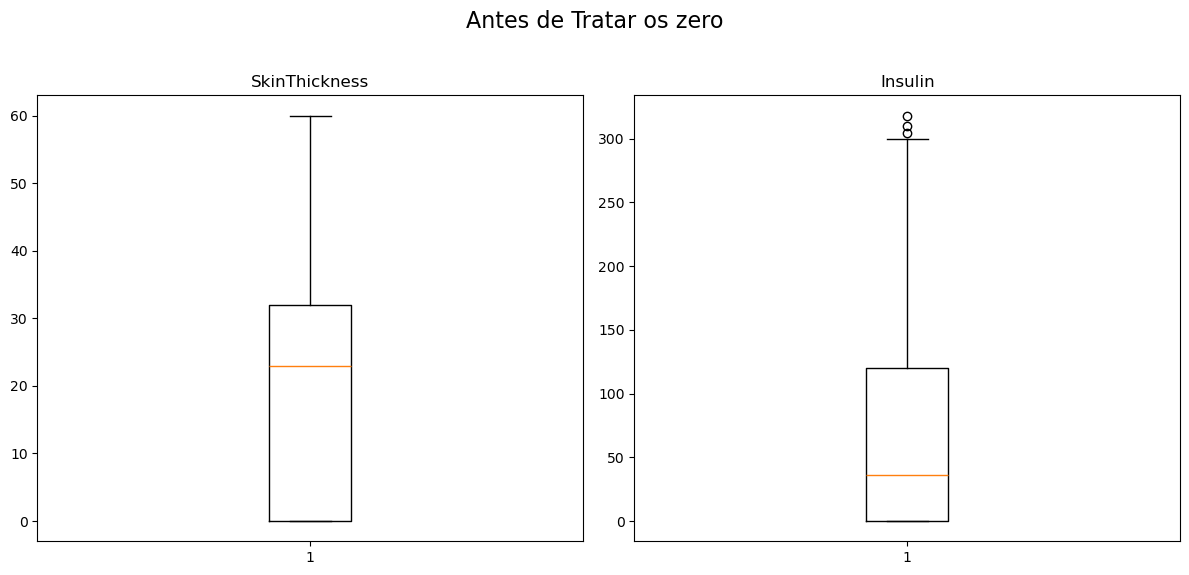

In [407]:
col_zeros = ['SkinThickness','Insulin']

plt.figure(figsize=(12,6))
for i, col in enumerate(col_zeros, 1):
    plt.subplot(1, 2, i)  # 1 linha, 2 colunas
    plt.boxplot(df[col])
    plt.title(col)

plt.suptitle("Antes de Tratar os zero", fontsize=16, y=0.95)
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [408]:
df[df['SkinThickness']==0] # Não é biologicamente possivel; #186 vamos por nan
df['SkinThickness'].replace(0, np.nan, inplace=True)

C:\Users\Francisco Guedes\AppData\Local\Temp\ipykernel_1364\2495675489.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SkinThickness'].replace(0, np.nan, inplace=True)


In [409]:
df[df['Insulin']==0] #317 rows. é muito....
df['Insulin'].replace(0, np.nan, inplace=True)

C:\Users\Francisco Guedes\AppData\Local\Temp\ipykernel_1364\2530109633.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Insulin'].replace(0, np.nan, inplace=True)


In [410]:
#Estrategia vai ser agrupar os valores pelo Outcome e para cada 0 ou 1 fazemos a mediana e preenchemos no nan de ['SkinThickness' e 'Insulin']

In [411]:
# Calcular mediana por grupo (ex: Outcome)
mediana_por_grupo_skin = df.groupby('Outcome')['SkinThickness'].transform('median')
mediana_por_grupo_ins = df.groupby('Outcome')['Insulin'].transform('median')

# Preencher NaNs com a mediana do grupo correspondente
df['SkinThickness'].fillna(mediana_por_grupo_skin, inplace=True)
df['Insulin'].fillna(mediana_por_grupo_ins, inplace=True)

# Conferir se ainda tem NaNs
print(df['SkinThickness'].isna().sum())
print(df['Insulin'].isna().sum())

0
0


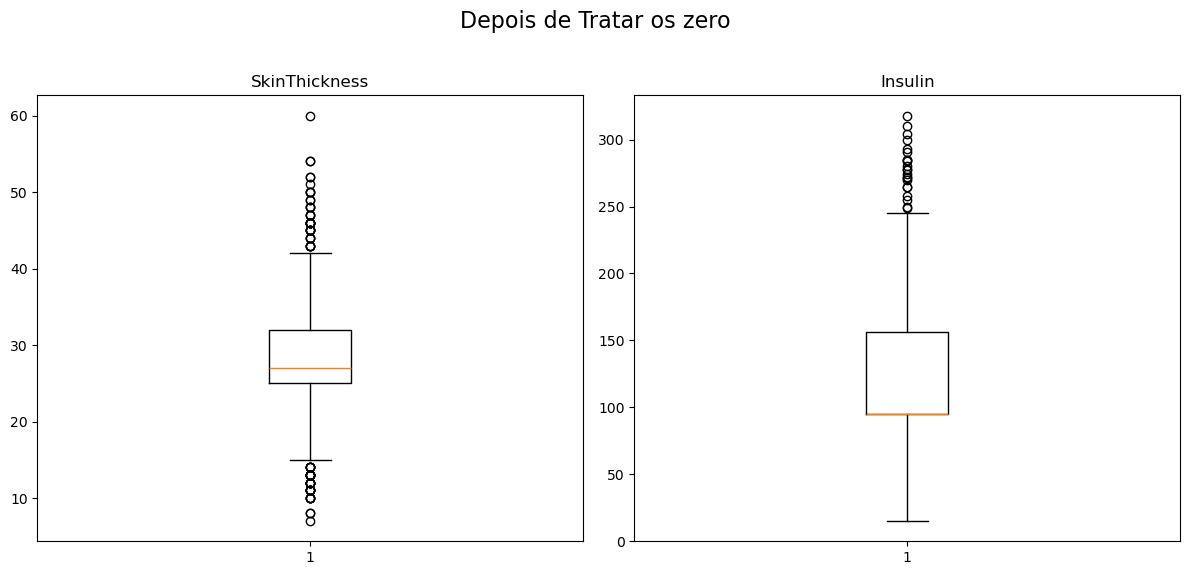

In [412]:
plt.figure(figsize=(12,6))
for i, col in enumerate(col_zeros, 1):
    plt.subplot(1, 2, i)  # 1 linha, 2 colunas
    plt.boxplot(df[col])
    plt.title(col)

plt.suptitle("Depois de Tratar os zero", fontsize=16, y=0.95)
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In [413]:
from sklearn.model_selection import train_test_split

X=df.drop(['Outcome'],axis=1)
y=df['Outcome']

X_train,X_test,ytrain,ytest = train_test_split(X,y,test_size=0.25,random_state=8)

In [414]:
from sklearn.preprocessing import StandardScaler

#Vou utilizar na PipeLine que faz por si
#scaler = StandardScaler()
#scaler.fit_transform(X_train)
#scaler.transform(X_test)

In [415]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline  # <- IMPORT CORRETO para utilizar o SMOTE
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE #Target desbalanceado

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),           # <- Balanceia durante o treino
    ('classifier', LinearSVC(max_iter=10000))  # placeholder
])

# Grid de parâmetros para testar vários classificadores
param_grid = [
    {'classifier': [LinearSVC(max_iter=10000)], 'classifier__C': [0.01, 0.1, 1, 10]},
    {'classifier': [LogisticRegression(max_iter=1000)], 'classifier__C': [0.01, 0.1, 1, 10]},
    {'classifier': [KNeighborsClassifier()], 'classifier__n_neighbors': [3,5,7]}
]

# GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, ytrain)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('classifier',
                                        LinearSVC(max_iter=10000))]),
             n_jobs=-1,
             param_grid=[{'classifier': [LinearSVC(max_iter=10000)],
                          'classifier__C': [0.01, 0.1, 1, 10]},
                         {'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.01, 0.1, 1, 10]},
                         {'classifier': [KNeighborsClassifier()],
                          'classifier__n_neighbors': [3, 5, 7]}],
             scoring='accuracy')

In [416]:
from sklearn.metrics import accuracy_score

# Avaliação
print("Melhor modelo:", grid.best_estimator_)
print("Melhores parâmetros:", grid.best_params_)
y_pred = grid.predict(X_test)
print("Acurácia no teste:", accuracy_score(ytest, y_pred))

Melhor modelo: Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE()),
                ('classifier', KNeighborsClassifier())])
Melhores parâmetros: {'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 5}
Acurácia no teste: 0.8048780487804879


In [417]:
from sklearn.metrics import classification_report #Verificar metricas de classificação

modelo_otimo=grid.best_estimator_
y_pred = modelo_otimo.predict(X_test)
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84       106
           1       0.69      0.81      0.75        58

    accuracy                           0.80       164
   macro avg       0.79      0.81      0.79       164
weighted avg       0.82      0.80      0.81       164



In [418]:
# Conclusões:

# 1. Acurácia geral: 0.84
#    - O modelo acerta cerca de 84% das amostras totais.
#    - Para datasets desbalanceados, a acurácia pode favorecer a classe majoritária.

# 2. Classe 0 (não diabético):
#    - Precision 0.90: quando o modelo prevê 0, acerta 90% das vezes.
#    - Recall 0.84: identifica 84% de todos os não diabéticos.
#    - F1-score 0.87: bom equilíbrio entre precisão e recall.

# 3. Classe 1 (diabético):
#    - Precision 0.74: quando o modelo prevê 1, acerta 74% das vezes.
#    - Recall 0.83: identifica 83% de todos os diabéticos.
#    - F1-score 0.78: razoável, menor que a classe 0.
#    - Mostra que o modelo consegue capturar a maior parte dos diabéticos, mas ainda confunde alguns negativos como positivos.

# 4. Impacto do desbalanceamento:
#    - A classe minoritária (1 = diabético) tem menor precisão.
#    - Macro avg (0.82) reflete desempenho médio simples entre classes.
#    - Weighted avg (0.84) reflete acurácia geral ponderada pelo número de amostras.

# 5. Conclusão prática:
#    - Modelo bem equilibrado, captura a maioria dos casos de diabetes (recall 0.83).
#    - Ideal para detecção precoce, mas ainda pode melhorar a precisão da classe 1.
#    - Sugestões de melhoria:
#        1. Ajustar hiperparâmetros (GridSearch mais fino).
#        2. Usar técnicas de balanceamento (SMOTE ou class_weight='balanced').
#        3. Testar modelos não lineares (RandomForest, XGBoost) para padrões complexos.

[[85 21]
 [11 47]]


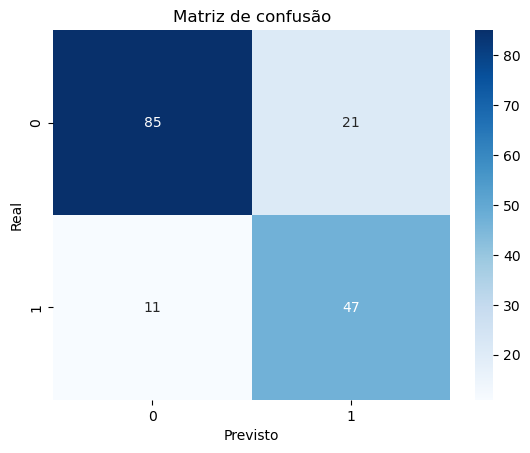

In [419]:
from sklearn.metrics import confusion_matrix #Avalia a acuracia do modelo

y_pred = modelo_otimo.predict(X_test)

cm = confusion_matrix(ytest,y_pred)
print(cm)

sns.heatmap(cm,annot=True,cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title("Matriz de confusão")
plt.show()

                    feature  importance
4                   Insulin    0.105488
1                   Glucose    0.035366
7                       Age    0.028049
3             SkinThickness    0.017073
2             BloodPressure    0.007317
0               Pregnancies    0.004878
6  DiabetesPedigreeFunction   -0.003049
5                       BMI   -0.014024


C:\Users\Francisco Guedes\AppData\Local\Temp\ipykernel_1364\249321596.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


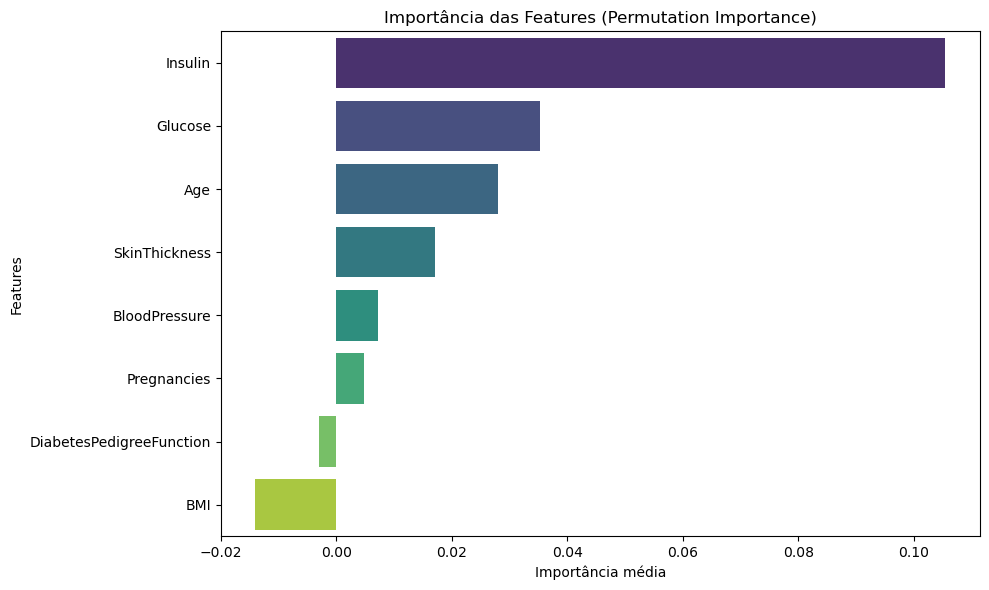

In [420]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelo_otimo, X_test, ytest, n_repeats=10, random_state=8)

importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': result.importances_mean})
importance_df.sort_values(by='importance', ascending=False, inplace=True)
print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title("Importância das Features (Permutation Importance)")
plt.xlabel("Importância média")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [421]:
import joblib
joblib.dump(modelo_otimo, "models/modelo_diabetes.pkl")

['models/modelo_diabetes.pkl']

In [422]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')